<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/04.quantum-kernel-classification/01.iris-qsvm/day27_02_08_qsvm_confusion_matrix_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day27 QSVM Confusion Matrix 실습

- Source: Google Drive `Day27/2-8.py`
- Runtime: Google Colab recommended. Do not install or execute dependencies locally for sync validation.


STEP 1. Library Import


Library Import Completed

STEP 2. Load Prediction
Samples : 30

STEP 3. Confusion Matrix
[[11  4]
 [ 0 15]]

STEP 4. TP / TN / FP / FN
True Negative  : 11
False Positive : 4
False Negative : 0
True Positive  : 15

STEP 5. DataFrame
                 Pred Negative  Pred Positive
Actual Negative             11              4
Actual Positive              0             15

STEP 6. Save CSV
Saved
output/confusion_matrix.csv

STEP 7. Save Pickle
output/confusion_matrix.pkl

STEP 8. Visualization


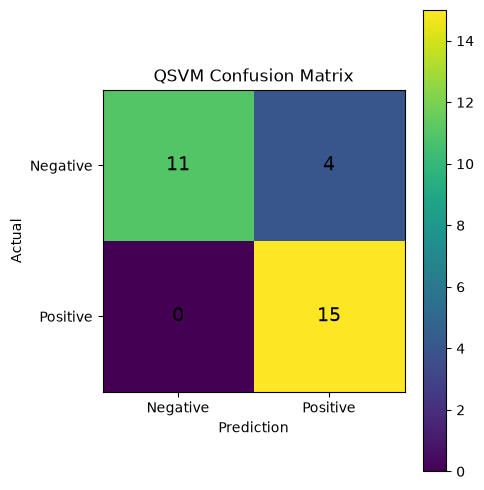

output/confusion_matrix.png

STEP 9. Error Analysis
Correct Prediction : 26
Wrong Prediction   : 4

False Positive : 4
False Negative : 0

False Positive가 더 많습니다.
Negative를 Positive로 잘못 예측하는 경우가 많습니다.

STEP 10. Interpretation
TN : 실제 Negative를 정확하게 예측
FP : 실제 Negative를 Positive로 예측
FN : 실제 Positive를 Negative로 예측
TP : 실제 Positive를 정확하게 예측

Confusion Matrix는
Accuracy보다 더 자세한 오류 분석을 제공합니다.

다음 실습에서는
ROC Curve와 AUC를 생성합니다.

CONFUSION MATRIX SUMMARY
                 Pred Negative  Pred Positive
Actual Negative             11              4
Actual Positive              0             15

TN : 11
FP : 4
FN : 0
TP : 15
Confusion Matrix Completed
Next Step : 2-9.py


In [1]:
"""
============================================================
Lab 15. QSVM Performance Evaluation


Confusion Matrix 생성 및 분석
------------------------------------------------------------
이번 실습에서는

1. Prediction 결과 불러오기
2. Confusion Matrix 생성
3. TP / TN / FP / FN 계산
4. DataFrame 변환
5. CSV 저장
6. Confusion Matrix 시각화
7. 결과 해석

============================================================
"""

# ============================================================
# STEP 1. Library Import
# ============================================================

print("=" * 70)
print("STEP 1. Library Import")
print("=" * 70)

import pickle

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

print("Library Import Completed")

# ============================================================
# STEP 2. Load Prediction
# ============================================================

print("\n" + "=" * 70)
print("STEP 2. Load Prediction")
print("=" * 70)

y_test = np.load("output/y_test.npy")
y_pred = np.load("output/y_prediction.npy")

print("Samples :", len(y_test))

# ============================================================
# STEP 3. Confusion Matrix
# ============================================================

print("\n" + "=" * 70)
print("STEP 3. Confusion Matrix")
print("=" * 70)

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

# ============================================================
# STEP 4. TP / TN / FP / FN
# ============================================================

print("\n" + "=" * 70)
print("STEP 4. TP / TN / FP / FN")
print("=" * 70)

TN, FP, FN, TP = cm.ravel()

print(f"True Negative  : {TN}")
print(f"False Positive : {FP}")
print(f"False Negative : {FN}")
print(f"True Positive  : {TP}")

# ============================================================
# STEP 5. DataFrame
# ============================================================

print("\n" + "=" * 70)
print("STEP 5. DataFrame")
print("=" * 70)

cm_df = pd.DataFrame(

    cm,

    index=[
        "Actual Negative",
        "Actual Positive"
    ],

    columns=[
        "Pred Negative",
        "Pred Positive"
    ]

)

print(cm_df)

# ============================================================
# STEP 6. Save CSV
# ============================================================

print("\n" + "=" * 70)
print("STEP 6. Save CSV")
print("=" * 70)

cm_df.to_csv(

    "output/confusion_matrix.csv"

)

print("Saved")

print("output/confusion_matrix.csv")

# ============================================================
# STEP 7. Save Pickle
# ============================================================

print("\n" + "=" * 70)
print("STEP 7. Save Pickle")
print("=" * 70)

cm_info = {

    "TN": int(TN),

    "FP": int(FP),

    "FN": int(FN),

    "TP": int(TP)

}

with open(

    "output/confusion_matrix.pkl",

    "wb"

) as f:

    pickle.dump(

        cm_info,

        f

    )

print("output/confusion_matrix.pkl")

# ============================================================
# STEP 8. Visualization
# ============================================================

print("\n" + "=" * 70)
print("STEP 8. Visualization")
print("=" * 70)

plt.figure(figsize=(5,5))

plt.imshow(cm)

plt.colorbar()

plt.xticks([0,1],["Negative","Positive"])

plt.yticks([0,1],["Negative","Positive"])

plt.xlabel("Prediction")

plt.ylabel("Actual")

plt.title("QSVM Confusion Matrix")

for i in range(2):

    for j in range(2):

        plt.text(

            j,

            i,

            cm[i,j],

            ha="center",

            va="center",

            fontsize=14

        )

plt.tight_layout()

plt.savefig(

    "output/confusion_matrix.png",

    dpi=200

)

plt.show()

print("output/confusion_matrix.png")

# ============================================================
# STEP 9. Error Analysis
# ============================================================

print("\n" + "=" * 70)
print("STEP 9. Error Analysis")
print("=" * 70)

total = TP + TN + FP + FN

correct = TP + TN

wrong = FP + FN

print(f"Correct Prediction : {correct}")

print(f"Wrong Prediction   : {wrong}")

print()

print(f"False Positive : {FP}")

print(f"False Negative : {FN}")

print()

if FP > FN:

    print("False Positive가 더 많습니다.")

    print("Negative를 Positive로 잘못 예측하는 경우가 많습니다.")

elif FN > FP:

    print("False Negative가 더 많습니다.")

    print("Positive를 놓치는 경우가 많습니다.")

else:

    print("False Positive와 False Negative가 비슷합니다.")

# ============================================================
# STEP 10. Interpretation
# ============================================================

print("\n" + "=" * 70)
print("STEP 10. Interpretation")
print("=" * 70)

print("TN : 실제 Negative를 정확하게 예측")

print("FP : 실제 Negative를 Positive로 예측")

print("FN : 실제 Positive를 Negative로 예측")

print("TP : 실제 Positive를 정확하게 예측")

print()

print("Confusion Matrix는")

print("Accuracy보다 더 자세한 오류 분석을 제공합니다.")

print()

print("다음 실습에서는")

print("ROC Curve와 AUC를 생성합니다.")

# ============================================================
# STEP 11. Summary
# ============================================================

print("\n" + "=" * 70)
print("CONFUSION MATRIX SUMMARY")
print("=" * 70)

print(cm_df)

print()

print(f"TN : {TN}")

print(f"FP : {FP}")

print(f"FN : {FN}")

print(f"TP : {TP}")

print("=" * 70)

print("Confusion Matrix Completed")

print("Next Step : 2-9.py")

print("=" * 70)